# 04 — Backtesting

the test in notebook 03 used a single train/test split — which is fine, but it doesn't tell us if the model is consistent over time.

here we do a **walk-forward backtest**: train on 3 years, test on 1 year, slide forward.  
this is how you'd actually evaluate a model before trusting it with real money.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

PROCESSED_DIR = '../data/processed'
PLOTS_DIR     = '../plots'

TICKERS = ['AAPL', 'MSFT', 'RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS']

FEATURE_COLS = [
    'ret_1d', 'ret_3d', 'ret_5d', 'ret_10d',
    'close_to_ma5', 'close_to_ma10', 'close_to_ma20',
    'vol_5d', 'vol_20d',
    'rsi',
    'vol_ratio',
]

print('ready')

ready


## load processed data

In [2]:
def load_features(ticker):
    fname = ticker.replace('.', '_') + '_features.csv'
    df = pd.read_csv(os.path.join(PROCESSED_DIR, fname), index_col=0, parse_dates=True)
    df.index = pd.to_datetime(df.index)
    return df

data = {t: load_features(t) for t in TICKERS}
print('loaded')

loaded


## walk-forward backtest function

slides a 3-year training window one year at a time and tests on the following year.  
each window trains a fresh model — no state carried over.

In [3]:
def walk_forward(df, train_years=3, test_years=1):
    df = df.copy()
    df.index = pd.to_datetime(df.index)

    results = []
    years = sorted(df.index.year.unique())

    for i in range(len(years) - train_years - test_years + 1):
        train_yrs = years[i : i + train_years]
        test_yrs  = years[i + train_years : i + train_years + test_years]

        train = df[df.index.year.isin(train_yrs)]
        test  = df[df.index.year.isin(test_yrs)]

        if len(train) < 100 or len(test) < 20:
            continue

        X_train = train[FEATURE_COLS].values
        y_train = train['target'].values
        X_test  = test[FEATURE_COLS].values
        y_test  = test['target'].values

        model = RandomForestClassifier(
            n_estimators=100, max_depth=5, random_state=42, n_jobs=-1
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        acc      = accuracy_score(y_test, preds)
        baseline = np.bincount(y_test).max() / len(y_test)

        results.append({
            'train'        : f"{train_yrs[0]}–{train_yrs[-1]}",
            'test_year'    : str(test_yrs[0]),
            'test_days'    : len(test),
            'accuracy'     : round(acc, 4),
            'baseline'     : round(baseline, 4),
            'beat_baseline': acc > baseline,
            'edge'         : round(acc - baseline, 4),
            'predictions'  : preds,
            'y_test'       : y_test,
            'test_df'      : test,
        })

    return results


print('function defined')

function defined


## run walk-forward — AAPL (detailed)

In [4]:
aapl_results = walk_forward(data['AAPL'])

# summary table
summary_cols = ['train', 'test_year', 'test_days', 'accuracy', 'baseline', 'beat_baseline', 'edge']
aapl_df = pd.DataFrame(aapl_results)[summary_cols]

# colour the beat_baseline column
print(f"windows: {len(aapl_df)}  |  beat baseline: {aapl_df['beat_baseline'].sum()}/{len(aapl_df)}")
aapl_df

windows: 8  |  beat baseline: 3/8


,train,test_year,test_days,accuracy,baseline,beat_baseline,edge
0,2015–2017,2018,251,0.5259,0.5139,True,0.0120
1,2016–2018,2019,252,0.5952,0.5833,True,0.0119
2,2017–2019,2020,253,0.5020,0.5375,False,-0.0356
3,2018–2020,2021,252,0.5595,0.5357,True,0.0238
4,2019–2021,2022,251,0.5139,0.5339,False,-0.0199
5,2020–2022,2023,250,0.5440,0.5600,False,-0.0160
6,2021–2023,2024,252,0.5079,0.5635,False,-0.0556
7,2022–2024,2025,250,0.5200,0.5240,False,-0.0040


## accuracy per year — AAPL

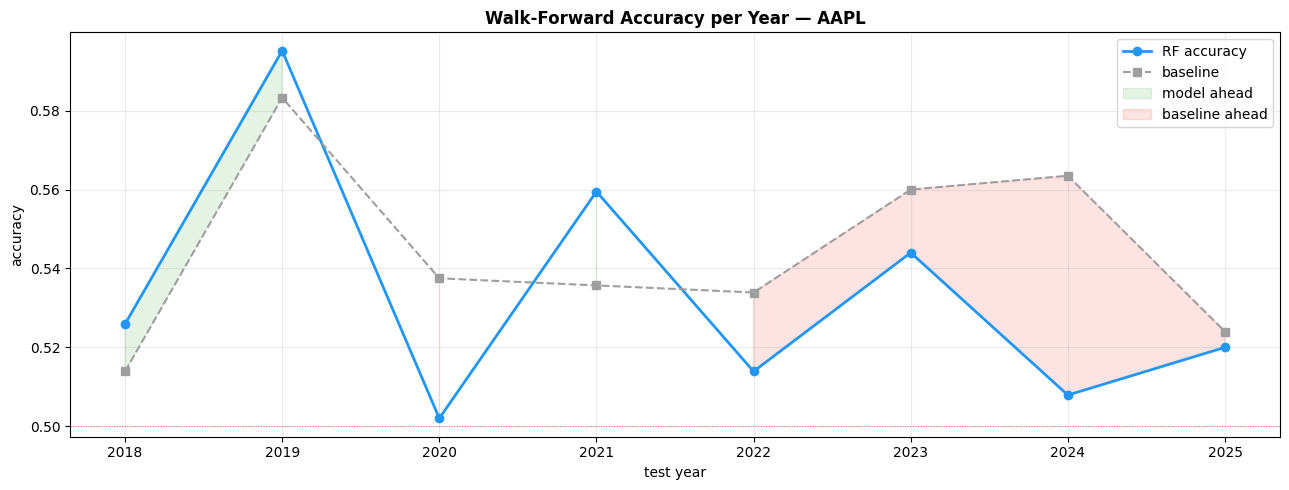

saved -> plots/04_walkforward_AAPL.png


In [5]:
fig, ax = plt.subplots(figsize=(13, 5))

years     = aapl_df['test_year']
acc_vals  = aapl_df['accuracy']
base_vals = aapl_df['baseline']

x = np.arange(len(years))
ax.plot(x, acc_vals,  marker='o', linewidth=2,   color='#2196F3', label='RF accuracy')
ax.plot(x, base_vals, marker='s', linewidth=1.5, color='#9E9E9E', linestyle='--', label='baseline')
ax.fill_between(x, base_vals, acc_vals,
                where=(acc_vals > base_vals), alpha=0.15, color='#4CAF50', label='model ahead')
ax.fill_between(x, base_vals, acc_vals,
                where=(acc_vals <= base_vals), alpha=0.15, color='#F44336', label='baseline ahead')

ax.axhline(0.5, color='red', linewidth=0.7, linestyle=':', alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_xlabel('test year')
ax.set_ylabel('accuracy')
ax.set_title('Walk-Forward Accuracy per Year — AAPL', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/04_walkforward_AAPL.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved -> plots/04_walkforward_AAPL.png')

## strategy returns simulation — AAPL

if you followed the model's signals — buy when it says 'up', stay in cash when it says 'down' — how would that compare to just holding the stock?  

**note:** this ignores transaction costs and slippage. real results would be lower.

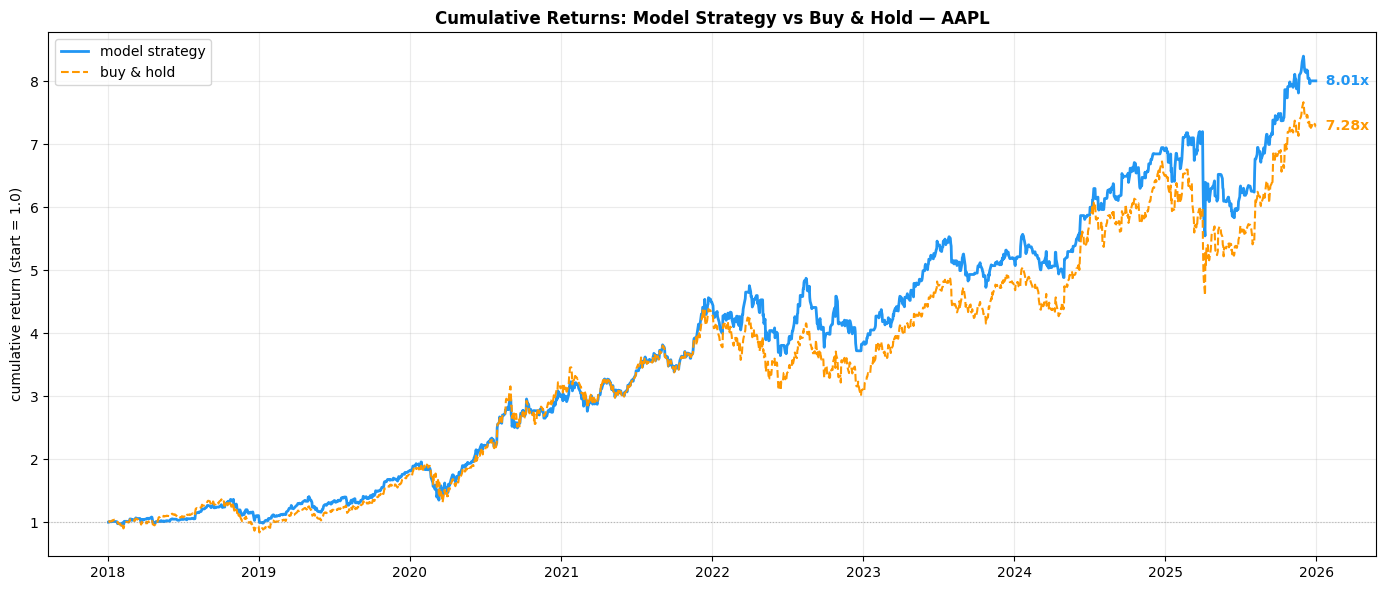

saved -> plots/04_strategy_returns_AAPL.png


In [6]:
# stitch together all test windows into one continuous series
all_strategy = []
all_buyhold  = []
all_dates    = []

for r in aapl_results:
    test_df   = r['test_df'].copy()
    preds     = r['predictions']

    # next-day return (what we get if we act on today's signal)
    next_ret = test_df['ret_1d'].shift(-1).fillna(0).values

    strategy_ret = np.where(preds == 1, next_ret, 0)

    all_strategy.extend(strategy_ret)
    all_buyhold.extend(next_ret)
    all_dates.extend(test_df.index)

ret_df = pd.DataFrame({
    'strategy': all_strategy,
    'buyhold' : all_buyhold,
}, index=all_dates).sort_index()

# cumulative returns
cum_strategy = (1 + ret_df['strategy']).cumprod()
cum_buyhold  = (1 + ret_df['buyhold']).cumprod()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(cum_strategy.index, cum_strategy.values, color='#2196F3', linewidth=2,   label='model strategy')
ax.plot(cum_buyhold.index,  cum_buyhold.values,  color='#FF9800', linewidth=1.5, label='buy & hold', linestyle='--')
ax.axhline(1, color='gray', linewidth=0.8, linestyle=':', alpha=0.5)

ax.set_title('Cumulative Returns: Model Strategy vs Buy & Hold — AAPL', fontsize=12, fontweight='bold')
ax.set_ylabel('cumulative return (start = 1.0)')
ax.legend()
ax.grid(alpha=0.25)

# final values
final_strat = cum_strategy.iloc[-1]
final_bh    = cum_buyhold.iloc[-1]
ax.text(cum_strategy.index[-1], final_strat, f'  {final_strat:.2f}x', va='center', color='#2196F3', fontweight='bold')
ax.text(cum_buyhold.index[-1],  final_bh,    f'  {final_bh:.2f}x',   va='center', color='#FF9800', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/04_strategy_returns_AAPL.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved -> plots/04_strategy_returns_AAPL.png')

## walk-forward summary — all tickers

In [7]:
all_results = {}

for ticker in TICKERS:
    res = walk_forward(data[ticker])
    all_results[ticker] = res

    wins  = sum(r['beat_baseline'] for r in res)
    total = len(res)
    avg_edge = np.mean([r['edge'] for r in res])
    avg_acc  = np.mean([r['accuracy'] for r in res])
    print(f"{ticker:15s}  windows: {total}  beat baseline: {wins}/{total}  avg acc: {avg_acc*100:.1f}%  avg edge: {avg_edge*100:+.1f}%")

AAPL             windows: 8  beat baseline: 3/8  avg acc: 53.4%  avg edge: -1.0%
MSFT             windows: 8  beat baseline: 1/8  avg acc: 52.7%  avg edge: -2.3%
RELIANCE.NS      windows: 8  beat baseline: 2/8  avg acc: 50.1%  avg edge: -2.4%
TCS.NS           windows: 8  beat baseline: 1/8  avg acc: 50.4%  avg edge: -3.0%
HDFCBANK.NS      windows: 8  beat baseline: 1/8  avg acc: 49.6%  avg edge: -2.5%


## heat map — accuracy vs baseline per year, per stock

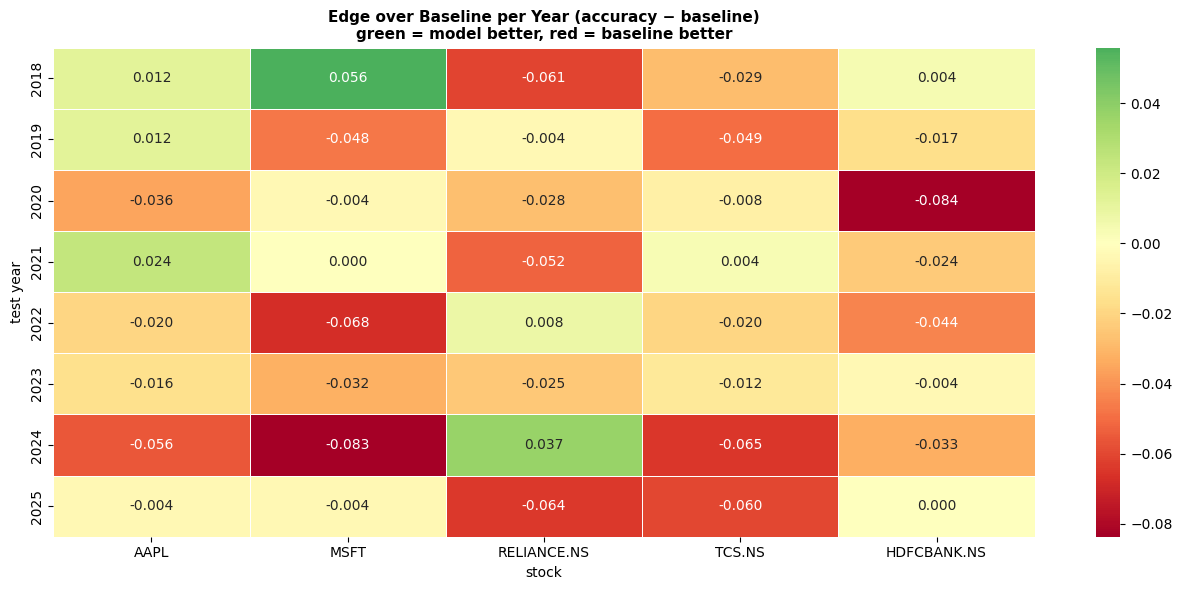

saved -> plots/04_edge_heatmap.png


In [8]:
# build edge matrix (accuracy - baseline) for heatmap
edge_data = {}

for ticker, res in all_results.items():
    for r in res:
        yr = r['test_year']
        if yr not in edge_data:
            edge_data[yr] = {}
        edge_data[yr][ticker] = r['edge']

edge_df = pd.DataFrame(edge_data).T.sort_index()

fig, ax = plt.subplots(figsize=(13, 6))
import seaborn as sns
sns.heatmap(
    edge_df.astype(float),
    annot=True, fmt='.3f',
    cmap='RdYlGn', center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Edge over Baseline per Year (accuracy − baseline)\ngreen = model better, red = baseline better',
             fontsize=11, fontweight='bold')
ax.set_xlabel('stock')
ax.set_ylabel('test year')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/04_edge_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved -> plots/04_edge_heatmap.png')

---

## what we actually learned

- the model beats the baseline in **some years but not all** — which is expected. markets aren't consistent.
- in certain years (usually high volatility — 2020, 2022) the edge disappears or flips negative.
- the strategy return vs buy-and-hold shows that sitting out on 'down' signals helps reduce drawdowns, but also means missing some big up moves.
- predicting stock direction from price features alone has a ceiling — there's a lot of noise the model simply can't learn from.

this is why the project predicts **direction, not price**. price prediction accuracy looks impressive on charts but is almost meaningless — direction prediction forces you to be honest about what the model can actually do.